# Binary Search Tree

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gao-hongnan/omniverse/blob/main/omniverse/dsa/tree/binary_search_tree.ipynb)

```{contents}
:local:
```

In [1]:
%config InlineBackend.figure_format = 'svg'

from __future__ import annotations

import rich
from typing import Optional, List, Union
import networkx as nx
import matplotlib.pyplot as plt


from omnivault.dsa.trees.binary import BinaryTreeNode
from omnivault.dsa.trees.utils import build_binary_tree_from_list_preorder
from omnivault.dsa.trees.utils import print_binary_tree

## Introduction

**[Binary Search Trees](https://en.wikipedia.org/wiki/Binary_search_tree)**
(BST) are a specific type of
**[Binary Trees](https://en.wikipedia.org/wiki/Binary_tree)** that provide
efficient solutions for many common problems. Each node in a BST has a key, and
no two nodes have the same key. This makes BST a useful data structure for
things like lookup tables and databases.

The key property of a BST is that for every node X, all keys in its left subtree
are smaller than the key in X, and all keys in its right subtree are larger than
the key in X. This property makes searching operations very efficient on BSTs.

Just like trees and binary trees, BSTs have many important applications in
computer science:

-   **Database Systems**: BSTs are widely used in database systems to enable
    fast search, insert, delete, and update operations.

-   **Memory Management**: BSTs can be used for memory management in operating
    systems.

-   **Sorting Algorithms**: In-order traversal of a BST results in sorted keys,
    and this property is used in sorting algorithms.

Despite their apparent simplicity, mastering BSTs is crucial to understanding,
designing, and implementing effective algorithms and data structures. For more
comprehensive information on BSTs, you can visit
[Wikipedia](https://en.wikipedia.org/wiki/Binary_search_tree).

## Definition

```{prf:definition} Binary Search Tree
:label: bst-definition

A **Binary Search Tree** (BST) is a type of
**[Binary Tree](https://en.wikipedia.org/wiki/Binary_tree)** where each node has
a key, and no two nodes have the same key.

Notably, for every node in the BST, the values of all
nodes in its left subtree are less than its own value, and the values of all
nodes in its right subtree are greater than its own value.

If we denote a binary tree as $T=(V, E, r)$, for it to qualify as a binary
search tree, it must satisfy these added conditions:

1. For any node $v$ with a left child $w$, the value of $w$ must be less than
   the value of $v$. Formally, this is expressed as: $\forall (v, w) \in E$, if
   $w$ is the left child of $v$ then $val(w) < val(v)$.

2. For any node $v$ with a right child $w$, the value of $w$ must be greater
   than the value of $v$. Formally, this is expressed as:
   $\forall (v, w) \in E$, if $w$ is the right child of $v$ then
   $val(w) > val(v)$.

These conditions ensure that all values in the left subtree of a node are less
than the node's value, and all values in the right subtree of a node are greater
than the node's value.

Here, $V$ is the set of nodes, $E$ is the set of edges, and $r$ is the root of
the tree. For a node $v$, $val(v)$ denotes its value.
```

## Example

Let's visualize a binary search tree. We will use the `networkx` library to
create and draw the trees.

Let's define a helper function `draw_tree` that takes in a list of edges, a
dictionary of positions, a title, and a subplot which we need to draw the tree.

In [2]:
def draw_tree(
    edges: List[Tuple[int, int]],
    positions: Dict[int, Tuple[float, float]],
    title: str,
    subplot: Axes,
) -> None:
    T = nx.DiGraph()
    T.add_edges_from(edges)
    nx.draw(
        T,
        positions,
        with_labels=True,
        node_color="skyblue",
        node_size=1500,
        edge_color="gray",
        ax=subplot,
    )
    subplot.set_title(title)

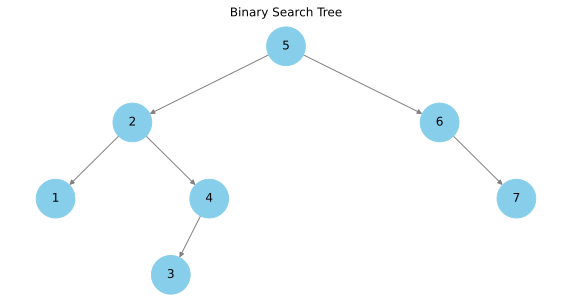

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
bst = [(5, 2), (2, 1), (2, 4), (4, 3), (5, 6), (6, 7)]
bst_positions = {
    5: (0, 0),
    2: (-2, -1),
    1: (-3, -2),
    4: (-1, -2),
    3: (-1.5, -3),
    6: (2, -1),
    7: (3, -2),
}
draw_tree(bst, bst_positions, "Binary Search Tree", ax)

### Counter-Example

In a Binary Search Tree (BST), the left child node
and all the nodes in its subtree should be less than the parent node. The right
child node and all the nodes in its subtree should be greater than the parent
node.

This rule applies to the entire subtree and not just the direct children of a
node.

So, if you have a root node of 10 and the right leaf of the left subtree is 11,
this would violate the property of the BST. Even though 11 is on the "right" of
its parent node in the left subtree, it is still part of the left subtree of the
root node 10. So it should be less than 10.

Here's a small example to illustrate this:

```text
     10
    /  \
   7    12
  / \   / \
 6   8 11  13
```

Here, even though 8 is the right child of 7, it's still in the left subtree of
the root node 10. So, it should be less than 10. Similarly, 11 is the left child
of 12, but it's in the right subtree of 10, so it should be greater than 10.

## Intuition

**Binary Search Trees (BST)** can also be understood intuitively with some
real-world examples. Here are a few:

**1. Sorted List:** Consider a sorted list of elements. The middle element in
the list could serve as the root of a binary search tree. All the elements to
the left of the root, which are less than the root, can be part of the left
subtree. Similarly, all elements to the right of the root, which are greater
than the root, can be part of the right subtree. This process can be applied
recursively to the left and right halves of the list to construct a binary
search tree.

**2. Decision Tree:** Binary search trees could also be imagined as decision
trees where each decision leads to a 'Yes' or 'No' (or true or false) leading to
the left or the right subtree respectively. For instance, let's say you're
playing a number guessing game where the number to guess is between 1 and 7. The
optimal strategy to guess the number with the fewest attempts is to start with
the middle value, i.e., 4. If the target number is less than 4, you know that
the number lies in the set {1, 2, 3} (left subtree). Otherwise, it lies in the
set {5, 6, 7} (right subtree). You can continue this process until you find the
target number. This forms a binary search tree where the root is 4, and its left
child is 2 and the right child is 6, and so on.

**3. Database Indexing:** Binary Search Trees are also used in databases for
indexing. Suppose you have a database with employee records and you want to find
the record of an employee with a specific ID. If the IDs are stored in a binary
search tree, you can efficiently locate the required ID. Starting from the root
of the BST, which could be a median value, you compare the target ID with the
current node ID. If the target is less, you move to the left child, if it's
more, you move to the right child. If the ID matches, you have found the record.
This process is much faster than a linear search through the records.

**4. Priority Queue:** A binary search tree can be used to implement a priority
queue. The root of the BST could represent the highest (or lowest, depending on
the implementation) priority element. When a new element is inserted into the
priority queue, it's placed in the appropriate position in the BST based on its
priority. When an element is dequeued, it's always the root of the BST that is
removed, ensuring that the highest priority element is always dequeued first.
The BST is then re-adjusted to maintain its properties.

In all these examples, the key feature of a binary search tree is maintained:
for any given node, all elements in its left subtree are less than the node, and
all elements in its right subtree are greater than the node. This property makes
binary search trees an efficient data structure for many types of operations.

## If a Binary Tree is a BST, then its In-order Traversal is a Sorted in Ascending Order

```{prf:theorem} In-order Traversal of a Binary Search Tree is Sorted
:label: bst-inorder-traversal-sorted

If a Binary Tree is a BST, then its In-order Traversal is Sorted in
Ascending Order.
```

```{prf:proof}
We prove this by induction.

**Base Case**: For an empty tree or a tree with one node, the in-order traversal
produces an empty sequence or a sequence with one element, which is sorted.

**Inductive Step**: Assume that for all binary search trees $T'$ of height less
than $h$, the in-order traversal is sorted.

Let's consider a binary search tree $T$ of height $h$. By definition of BST,
every node $x$ in the left subtree $L$ of the root of $T$ has a key less than
the key of the root $k_{root}$ and every node $y$ in the right subtree $R$ of
the root of $T$ has a key greater than the key of the root i.e.,
$k_{x} < k_{root} < k_{y}$.

By the inductive hypothesis, the in-order traversal of the left subtree $L$
gives a sorted sequence of keys $\text{Seq}_L$. Then visiting the root node adds
a key $k_{root}$ greater than all the keys in $\text{Seq}_L$. Finally, the
in-order traversal of the right subtree $R$ (which by the inductive hypothesis
is also sorted) adds keys that are greater than $k_{root}$. Therefore, the
in-order traversal of $T$ is sorted. This completes the induction step and
proves the first theorem.
```

## If an In-order Traversal of a Binary Tree is Sorted in Ascending Order, then the Binary Tree is a BST

```{prf:theorem} In-order Traversal of a Binary Tree is Sorted
:label: bst-inorder-traversal-sorted-converse

If an In-order Traversal of a Binary Tree is Sorted in Ascending
Order, then the Binary Tree is a BST
```

```{prf:proof}
We will prove by contradiction.

**Assume** that a binary tree $T$ has an in-order traversal $\text{Seq}_T$ that is
sorted in ascending order, but $T$ is not a binary search tree.

Since $T$ is not a BST, there exists at least one node $n$ in $T$ that violates
the binary search tree property. That means:

1. There is a node $a$ in the left subtree $L$ of $n$ that has a key greater
   than the key of $n$, or
2. There is a node $b$ in the right subtree $R$ of $n$ that has a key less than
   the key of $n$.

In the case of (1), since the in-order traversal visits all nodes of $L$ before
visiting $n$, there exists a key $k_a > k_n$ before $k_n$ in $\text{Seq}_T$, which
contradicts the assumption that $\text{Seq}_T$ is sorted in ascending order.

In the case of (2), since the in-order traversal visits $n$ before visiting any
nodes in $R$, there exists a key $k_b < k_n$ after $k_n$ in $\text{Seq}_T$, which
contradicts the assumption that $\text{Seq}_T$ is sorted in ascending order.

Therefore, we have a contradiction and our assumption that $T$ is not a BST must
be wrong. Hence, if an in-order traversal of a binary tree is sorted in
ascending order, the binary tree must be a BST.
```

See similar proof
**[here](https://cs.stackexchange.com/questions/95329/if-inorder-traversal-of-a-tree-is-in-ascending-order-will-the-tree-definitely-be)**.

## References and Further Readings

- **[Leetcode Card: Binary Tree](https://leetcode.com/explore/learn/card/introduction-to-data-structure-binary-search-tree/)**